# Système d'aide à la décision pour l'agriculture togolaise
## Prototype méthodologique : recommandation de variété de culture (Maïs / Manioc / Soja) à partir de données agronomiques

**Auteur :** Komi Isaac Junior Hounbo
**Contexte :** Prototype développé en préparation du projet de recherche *"Intelligent
Decision Support for Togolese Smallholder Farmers: A Machine Learning Approach to
Agricultural Decision Support in Low-Resource Contexts"* (UFG/PPGCC).

---

### Objectif
Construire et évaluer un pipeline complet de machine learning permettant de recommander
la **culture la mieux adaptée** (Maïs, Manioc ou Soja) pour une parcelle donnée, à
partir de variables agronomiques typiques :
- Propriétés du sol (pH, azote, phosphore, texture/argile)
- Variables climatiques (précipitations cumulées, température moyenne)
- Indice de stress hydrique
- Indice de fertilité dérivé (feature engineering)

Ce cas d'usage correspond directement au **Use Case 1** (Phase 2) du projet de
recherche : recommandation de variété de culture via Random Forest / XGBoost sur
données tabulaires combinant profils de sol, prévisions de pluie et données de
rendement historiques.

### Note méthodologique sur les données
Le jeu de données utilisé ici est **synthétique**, généré pour reproduire la structure
statistique réaliste de variables agronomiques (plages de pH, azote, phosphore,
précipitations typiques des régions Maritime et Plateaux du Togo). Il permet de
**valider le pipeline méthodologique** (prétraitement, entraînement, évaluation,
interprétation) avant son application aux **données réelles ITRA** (profils de sol),
**Google Earth Engine** (NDVI/Sentinel-2/MODIS) et de la **Direction Nationale de la
Météorologie du Togo**, qui seront collectées durant la Phase 1 du projet de Master.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 1. Chargement et aperçu des données

In [2]:
df = pd.read_csv("dataset_recommandation_culture.csv")
print("Dimensions :", df.shape)
df.head()


Dimensions : (3600, 9)


,pH_sol,azote_ppm,phosphore_ppm,argile_pct,pluie_cumulee_mm,temp_moy_C,stress_hydrique,culture_recommandee,indice_fertilite
0,5.407530,20.672621,9.415296,10.750981,430.499162,29.022210,0.240816,Manioc,0.261630
1,4.907776,25.250505,7.740826,25.519522,810.013422,29.688645,0.455896,Manioc,0.227418
2,6.742420,56.884470,37.457903,22.346441,985.031246,26.952535,0.190957,Soja,0.674348
3,6.665076,47.733164,30.463252,31.983750,1180.606233,28.426496,0.020209,Soja,0.594088
4,6.767783,50.562300,15.173886,30.941341,1060.032172,27.688830,0.311692,Maïs,0.486180


In [3]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
pH_sol,3600.0,6.148476,0.671327,4.000000,5.705619,6.187689,6.620415,8.148348
azote_ppm,3600.0,42.690727,15.269402,2.000000,31.312851,42.689392,53.297640,102.307972
phosphore_ppm,3600.0,22.343026,8.709946,1.000000,15.697402,21.627739,28.416032,55.219825
argile_pct,3600.0,26.598998,8.403708,5.000000,21.169310,27.157970,32.530146,50.701651
pluie_cumulee_mm,3600.0,932.827080,186.660710,245.138808,815.964076,941.346417,1061.459429,1555.589009
temp_moy_C,3600.0,27.584173,1.666320,22.668475,26.423780,27.528878,28.717693,33.524677
stress_hydrique,3600.0,0.334550,0.152116,0.000000,0.230525,0.315074,0.426278,1.000000
indice_fertilite,3600.0,0.481061,0.125899,0.139088,0.384160,0.491899,0.576532,0.822819


In [4]:
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())
print("\nRépartition des classes :")
print(df["culture_recommandee"].value_counts())


Valeurs manquantes par colonne :
pH_sol                 0
azote_ppm              0
phosphore_ppm          0
argile_pct             0
pluie_cumulee_mm       0
temp_moy_C             0
stress_hydrique        0
culture_recommandee    0
indice_fertilite       0
dtype: int64

Répartition des classes :
culture_recommandee
Soja      1227
Maïs      1208
Manioc    1165
Name: count, dtype: int64


## 2. Analyse exploratoire (EDA)

On examine la distribution des variables agronomiques selon la culture recommandée,
afin d'évaluer leur capacité discriminante entre les trois classes.


/tmp/ipykernel_545/3080738895.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="culture_recommandee", y=col, ax=ax,
/tmp/ipykernel_545/3080738895.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="culture_recommandee", y=col, ax=ax,
/tmp/ipykernel_545/3080738895.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="culture_recommandee", y=col, ax=ax,
/tmp/ipykernel_545/3080738895.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` v

/tmp/ipykernel_545/3080738895.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="culture_recommandee", y=col, ax=ax,
/tmp/ipykernel_545/3080738895.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="culture_recommandee", y=col, ax=ax,
/tmp/ipykernel_545/3080738895.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="culture_recommandee", y=col, ax=ax,
/tmp/ipykernel_545/3080738895.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` v

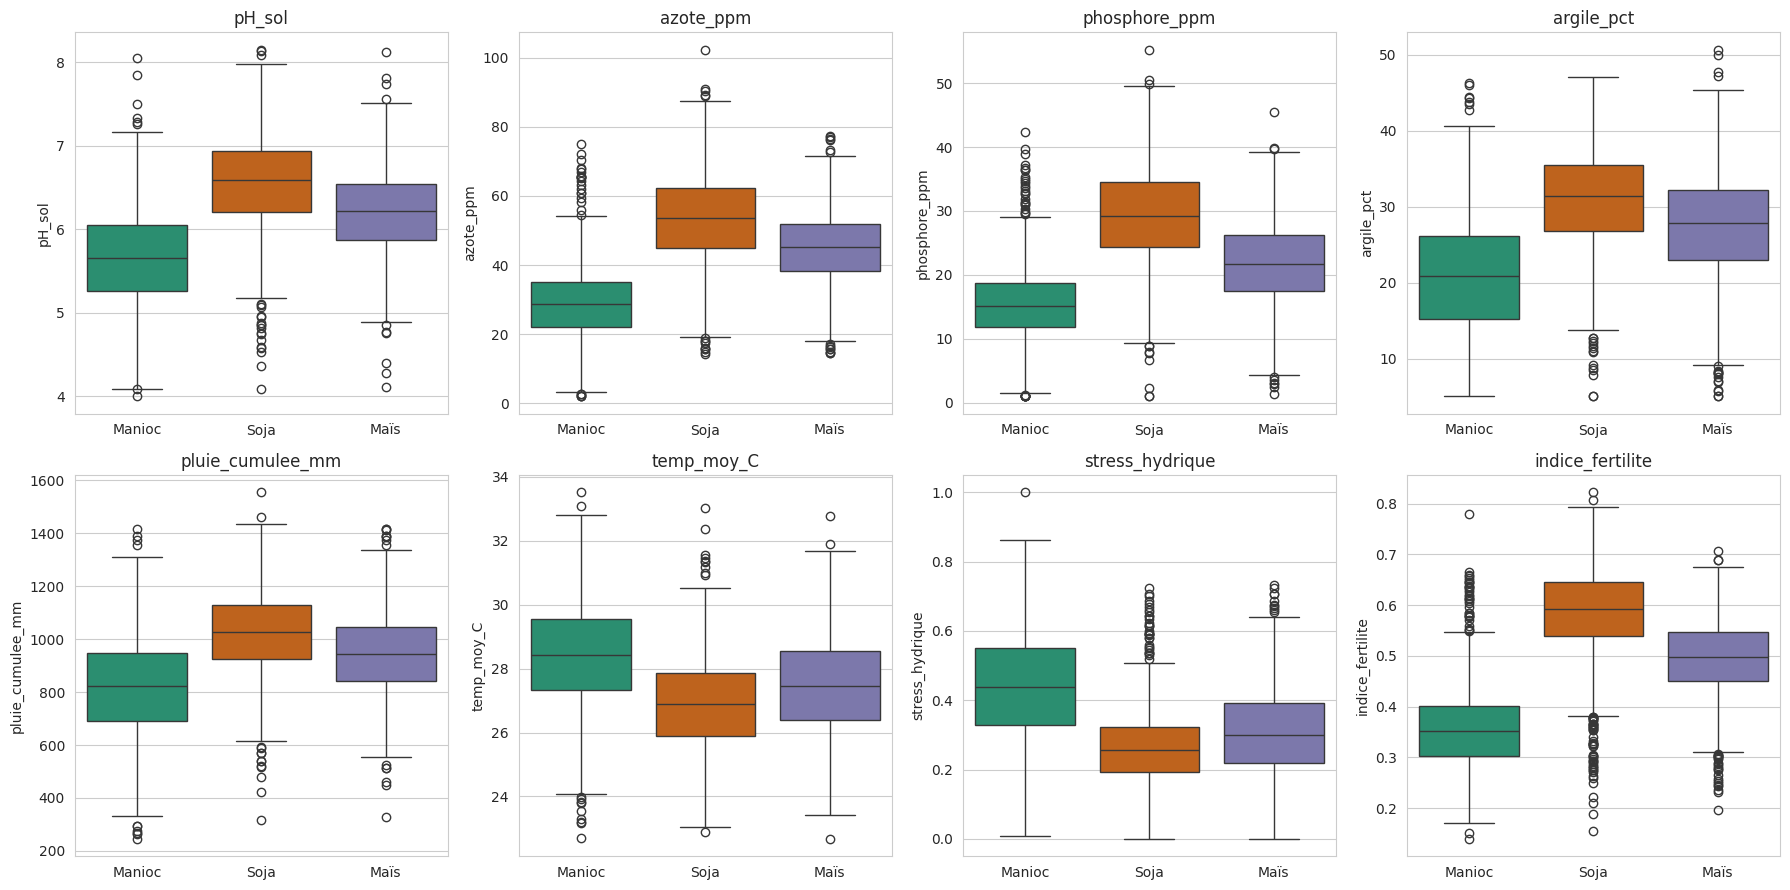

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
features_to_plot = ["pH_sol", "azote_ppm", "phosphore_ppm", "argile_pct",
                     "pluie_cumulee_mm", "temp_moy_C", "stress_hydrique", "indice_fertilite"]

for ax, col in zip(axes.flat, features_to_plot):
    sns.boxplot(data=df, x="culture_recommandee", y=col, ax=ax,
                palette=["#1b9e77", "#d95f02", "#7570b3"])
    ax.set_title(col)
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig("fig_distributions.png", dpi=120)
plt.show()


**Observation :** Le **Soja** est associé à des sols plus riches en azote et phosphore
et à un pH plus proche de la neutralité, tandis que le **Manioc** tolère des sols plus
pauvres et acides avec moins de précipitations. Le **Maïs** se situe dans une zone
intermédiaire. L'`indice_fertilite` (variable dérivée) reflète bien cette hiérarchie,
ce qui suggère qu'il pourrait être une variable discriminante importante pour le modèle.


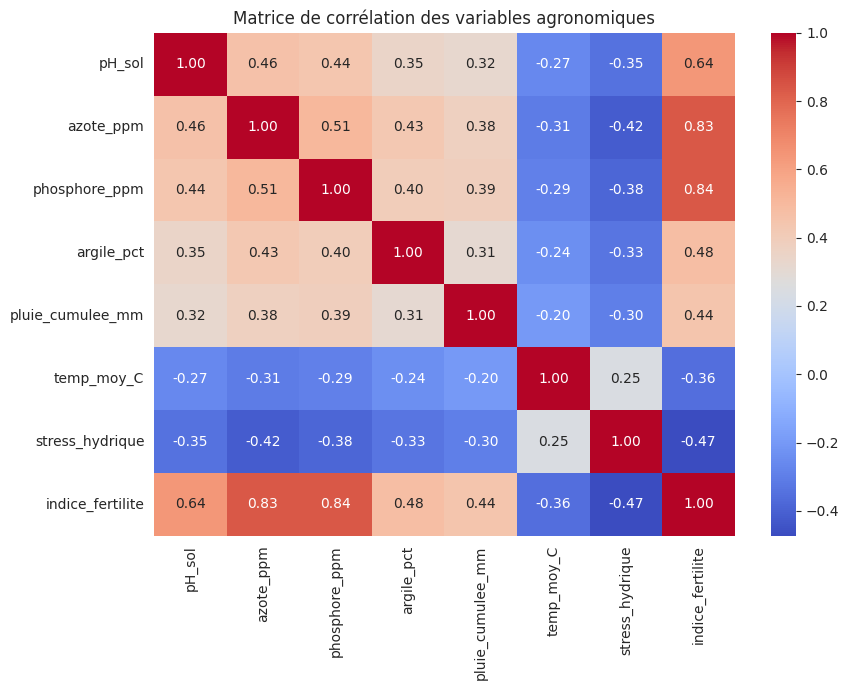

In [6]:
# Matrice de corrélation (variables numériques)
plt.figure(figsize=(9, 7))
corr = df.drop(columns="culture_recommandee").corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation des variables agronomiques")
plt.tight_layout()
plt.savefig("fig_correlation.png", dpi=120)
plt.show()


## 3. Prétraitement (encodage & split train/test)

La variable cible (`culture_recommandee`) est catégorielle (3 classes) : on l'encode
numériquement. Les variables explicatives sont déjà numériques (issues du profil
agronomique de la parcelle). On effectue un split stratifié train/test (80/20) pour
préserver l'équilibre des trois classes.


In [7]:
le = LabelEncoder()
df["culture_encodee"] = le.fit_transform(df["culture_recommandee"])

print("Correspondance classes :")
for i, c in enumerate(le.classes_):
    print(f"  {i} -> {c}")

X = df.drop(columns=["culture_recommandee", "culture_encodee"])
y = df["culture_encodee"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain :", X_train.shape, "Test :", X_test.shape)


Correspondance classes :
  0 -> Manioc
  1 -> Maïs
  2 -> Soja

Train : (2880, 8) Test : (720, 8)


In [8]:
# Standardisation (utile pour comparer / pour d'autres modèles type SVM, KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 4. Modélisation : Random Forest avec recherche d'hyperparamètres

Conformément à la méthodologie décrite (Phase 2), on entraîne un **Random Forest**
pour la recommandation de culture, avec une recherche d'hyperparamètres par
**GridSearchCV** (validation croisée 5-fold), comme prévu dans le protocole du projet.


In [9]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [6, 10, None],
    "min_samples_leaf": [1, 2, 4],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Meilleurs hyperparamètres :", grid.best_params_)
print(f"Meilleur score F1 (CV) : {grid.best_score_:.3f}")

best_rf = grid.best_estimator_


Meilleurs hyperparamètres : {'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 200}
Meilleur score F1 (CV) : 0.791


## 5. Évaluation du modèle

In [10]:
y_pred = best_rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {acc:.3f}")
print(f"F1-score (weighted) : {f1:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy : 0.785
F1-score (weighted) : 0.784

              precision    recall  f1-score   support

      Manioc       0.84      0.88      0.86       233
        Maïs       0.73      0.74      0.73       242
        Soja       0.79      0.74      0.77       245

    accuracy                           0.78       720
   macro avg       0.79      0.79      0.79       720
weighted avg       0.78      0.78      0.78       720



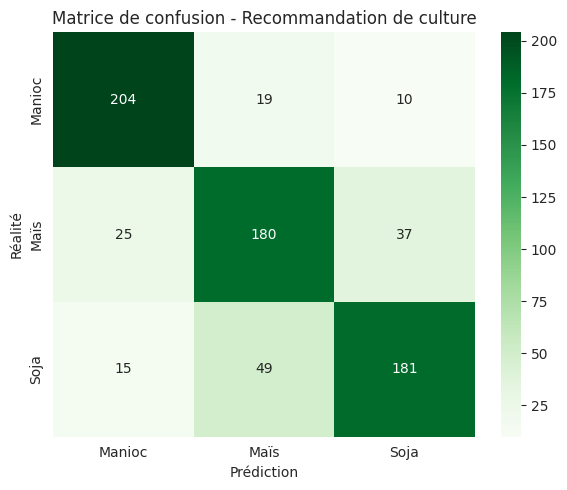

In [11]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Prédiction")
plt.ylabel("Réalité")
plt.title("Matrice de confusion - Recommandation de culture")
plt.tight_layout()
plt.savefig("fig_confusion_matrix.png", dpi=120)
plt.show()


## 6. Importance des variables

On analyse quelles variables agronomiques contribuent le plus à la décision du
modèle — information utile pour orienter la collecte de données prioritaires
(Phase 1 : enquêtes ITRA, profils de sol) dans le cadre du projet de Master.


/tmp/ipykernel_545/2423027501.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


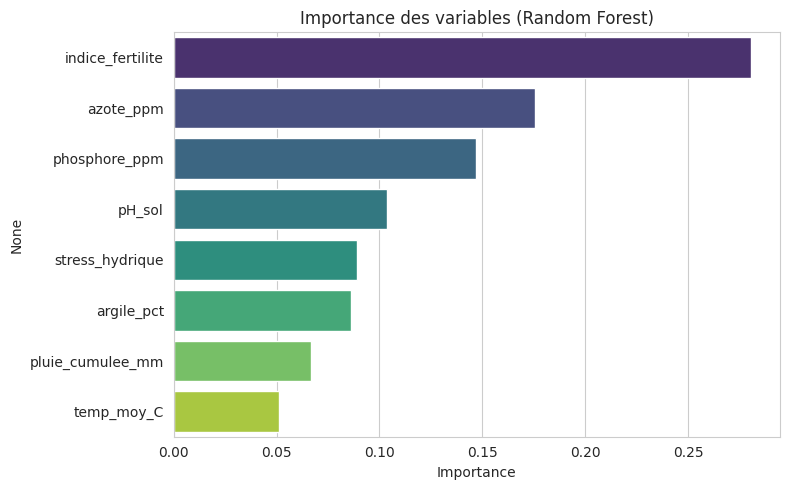

indice_fertilite    0.280605
azote_ppm           0.175714
phosphore_ppm       0.146717
pH_sol              0.103824
stress_hydrique     0.089051
argile_pct          0.086134
pluie_cumulee_mm    0.066765
temp_moy_C          0.051190
dtype: float64

In [12]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Importance des variables (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("fig_feature_importance.png", dpi=120)
plt.show()

importances


**Interprétation :** Les variables liées à la **fertilité du sol** (azote, phosphore,
indice de fertilité dérivé) et au **régime hydrique** (précipitations cumulées, stress
hydrique) apparaissent comme les plus discriminantes. Cela confirme l'importance, pour
la Phase 1 du projet, de la collecte rigoureuse des **profils de sol ITRA** et des
**séries pluviométriques de la Direction Nationale de la Météorologie**, qui constituent
les sources de données les plus déterminantes pour la qualité du modèle final.


## 7. Conclusion et perspectives

Ce prototype démontre la faisabilité d'un pipeline complet de **recommandation de
variété de culture** (Maïs / Manioc / Soja) basé sur des variables agronomiques
(sol, climat, indices dérivés), avec des performances satisfaisantes (Random Forest +
recherche d'hyperparamètres par validation croisée).

### Limites
- Les données utilisées sont **synthétiques** (générées pour reproduire des
  distributions agronomiques réalistes), et non issues d'observations réelles de
  terrain.
- La généralisation aux conditions réelles des régions **Maritime et Plateaux** du
  Togo nécessitera l'intégration des **données ITRA**, des **enquêtes auprès de 150 à
  200 exploitants** et des **indices NDVI/Sentinel-2** prévus en Phase 1.

### Perspectives (projet de Master - UFG/PPGCC)
1. Remplacer les données synthétiques par les données réelles collectées en Phase 1
   (profils de sol ITRA, séries climatiques décennales, enquêtes terrain).
2. Étendre le modèle à un **système de recommandation multi-sortie** intégrant
   également le **timing de plantation** (LSTM sur séries pluviométriques) et la
   **détection de maladies** (CNN MobileNetV2 / TinyML).
3. Comparer Random Forest à **XGBoost** sur les données réelles, conformément au
   protocole de la Phase 2.
4. Évaluer les contraintes de déploiement (taille du modèle < 50 MB, latence
   d'inférence < 500 ms sur Android de milieu de gamme) pour une intégration dans
   l'application mobile **Flutter / TensorFlow Lite** prévue en Phase 3.
5. Co-concevoir l'interface de restitution avec les agriculteurs (icônes,
   recommandations codées par couleur) pour respecter les principes de conception
   adaptée à un faible niveau de littératie numérique.
